### RaschPy thresholds MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 8 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Under the thresholds parameterisation, each rater has a separate severity for every threshold (shared across items), rather than a single scalar severity as in the global model.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import pandas as pd
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Thresholds(no_of_items=8, no_of_persons=40, no_of_facet_elements=4, max_score=5, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:391: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_32780/400418962.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': []}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=42` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set. 12 items, 8 raters, 200 persons, no missing data.

In [4]:
sim = rp.MFRM_Sim_Thresholds(no_of_items=12, no_of_persons=200, no_of_facet_elements=8, max_score=5, missing=0, seed=42)
sim.responses.to_csv('mfrm_thresholds_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_thresholds_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     3.0     4.0     4.0     1.0     4.0     3.0     3.0   
        Person_2     2.0     1.0     2.0     1.0     2.0     0.0     0.0   

                  Item_8  Item_9  Item_10  Item_11  Item_12  
Rater   Person                                               
Rater_1 Person_1     4.0     5.0      4.0      3.0      4.0  
        Person_2     2.0     2.0      1.0      1.0      0.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater,Person,,,,,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the thresholds parameterisation (a separate severity per rater x threshold combination, shared across items). The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_thresholds()

CPU times: user 3.49 ms, sys: 231 μs, total: 3.72 ms
Wall time: 3.67 ms


Check the item location estimates - view the first two items

In [10]:
mfrm.items.head(2)

Item_1   -1.078536
Item_2   -0.608357
dtype: float64

Since this is simulated data, we know the true generating item locations (`mfrm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')


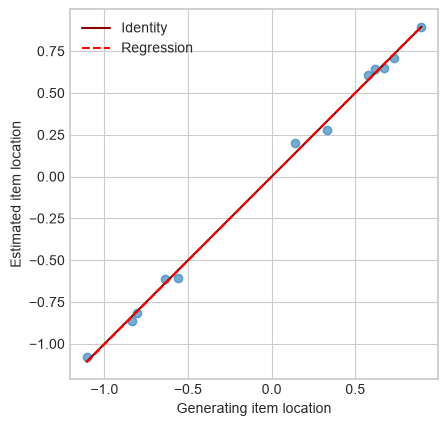

item location Pearson correlation:              0.999
item location SD ratio (estimated / generating): 1.004
item location regression coefficient:            1.003
item location RMSE:                              0.034


In [12]:
recovery_plot(mfrm.generating.items, mfrm.items, 'item location', 'my_mfrm_thresholds_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [13]:
%%time
mfrm.item_stats_df_thresholds(full=True)
mfrm.item_stats_thresholds.to_csv('mfrm_thresholds_item_stats.csv')

CPU times: user 16.2 s, sys: 73.8 ms, total: 16.3 s
Wall time: 16.3 s


Check the item statistics table

In [14]:
mfrm.item_stats_thresholds

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,-1.079,0.048,-1.174,-0.992,1600,0.695,1.111,3.045,1.065,1.813,0.702,0.725
Item_2,-0.608,0.038,-0.685,-0.538,1600,0.610,1.072,1.989,1.065,1.820,0.736,0.748
Item_3,-0.815,0.044,-0.907,-0.730,1600,0.650,1.022,0.618,1.005,0.150,0.723,0.738
Item_4,0.609,0.041,0.522,0.687,1600,0.407,1.013,0.385,1.021,0.592,0.768,0.775
Item_5,-0.866,0.040,-0.949,-0.794,1600,0.659,1.025,0.699,0.988,-0.321,0.723,0.736
Item_6,0.200,0.036,0.130,0.266,1600,0.485,0.990,-0.282,0.971,-0.815,0.776,0.772
Item_7,0.641,0.042,0.554,0.727,1600,0.400,1.070,1.932,1.081,2.239,0.772,0.775
Item_8,0.276,0.044,0.188,0.361,1600,0.455,1.104,2.844,1.071,1.962,0.760,0.772
Item_9,-0.614,0.040,-0.694,-0.537,1600,0.619,1.063,1.746,1.095,2.617,0.734,0.747
Item_10,0.896,0.041,0.822,0.978,1600,0.364,1.102,2.794,1.110,3.013,0.757,0.774


Generate a table of threshold statistics (and check run time), and save to file

In [15]:
%%time
mfrm.threshold_stats_df_thresholds(full=True)
mfrm.threshold_stats_thresholds.to_csv('mfrm_thresholds_threshold_stats.csv')

CPU times: user 67.7 ms, sys: 1.71 ms, total: 69.4 ms
Wall time: 69.2 ms


Check the threshold statistics table

In [16]:
mfrm.threshold_stats_thresholds

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-1.560,0.045,-1.638,-1.457,1.031,2.600,1.063,3.689,0.899,0.424,0.460
Threshold 2,-1.082,0.037,-1.144,-1.006,0.999,-0.088,1.001,0.042,1.002,0.439,0.445
Threshold 3,-0.665,0.030,-0.718,-0.606,0.992,-0.775,0.984,-0.918,1.022,0.518,0.544
Threshold 4,1.239,0.032,1.170,1.295,1.020,1.834,1.048,2.707,0.949,0.611,0.634
Threshold 5,2.068,0.047,1.958,2.147,1.027,1.999,1.034,1.533,0.941,0.590,0.612


And the same recovery check for thresholds, against `mfrm.generating.thresholds`:

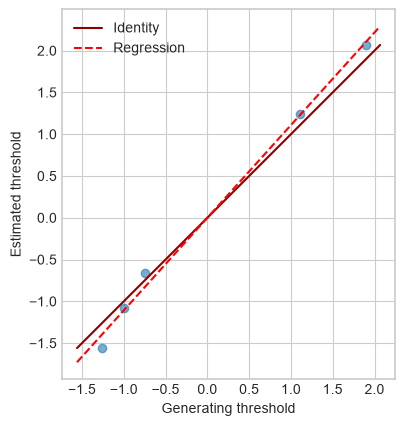

threshold Pearson correlation:              0.997
threshold SD ratio (estimated / generating): 1.112
threshold regression coefficient:            1.108
threshold RMSE:                              0.173


In [17]:
recovery_plot(mfrm.generating.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_thresholds_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file

In [18]:
%%time
mfrm.rater_stats_df_thresholds()
mfrm.rater_stats_thresholds.to_csv('mfrm_thresholds_rater_stats.csv')

CPU times: user 28.8 ms, sys: 752 μs, total: 29.5 ms
Wall time: 29.5 ms


Check the rater statistics table

In [19]:
mfrm.rater_stats_thresholds

Threshold 1        Threshold 2        Threshold 3        Threshold 4  \
           Estimate     SE    Estimate     SE    Estimate     SE    Estimate   
Rater_1      -0.224  0.087       0.220  0.085       1.081  0.080      -0.152   
Rater_2      -1.005  0.087      -0.130  0.087       0.343  0.074      -0.776   
Rater_3      -0.095  0.075       0.862  0.091       0.109  0.069       1.062   
Rater_4      -0.187  0.091       0.479  0.114      -0.765  0.091      -0.538   
Rater_5       0.325  0.101      -0.622  0.095       0.161  0.071       0.341   
Rater_6       0.074  0.085      -0.184  0.096       0.029  0.076      -0.004   
Rater_7       0.633  0.101       0.057  0.117      -0.259  0.082      -0.350   
Rater_8       0.477  0.093      -0.682  0.116      -0.698  0.081       0.417   

               Threshold 5        Overall statistics                     
            SE    Estimate     SE              Count Infit MS Outfit MS  
Rater_1  0.078       0.659  0.102             2400.0    1.080     1.052  
Rater_2  0.083      -0.816  0.074             2400.0    1.061     1.075  
Rater_3  0.089       0.057  0.122             2400.0    1.028     1.020  
Rater_4  0.062       0.404  0.085             2400.0    1.094     1.073  
Rater_5  0.075       0.412  0.090             2400.0    1.079     1.060  
Rater_6  0.072      -0.048  0.089             2400.0    1.017     0.993  
Rater_7  0.066       0.200  0.079             2400.0    1.040     1.053  
Rater_8  0.066      -0.869  0.106             2400.0    1.078     1.042

And the same recovery check for rater x threshold severities, against `mfrm.generating.facet_effects`. Since these are per rater x threshold, we flatten with `.unstack()` first:

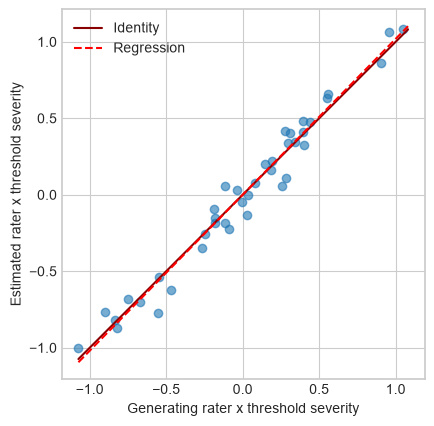

rater x threshold severity Pearson correlation:              0.984
rater x threshold severity SD ratio (estimated / generating): 1.036
rater x threshold severity regression coefficient:            1.019
rater x threshold severity RMSE:                              0.095


In [20]:
orig_severities = mfrm.generating.facet_effects.unstack()
est_severities = mfrm.raters_thresholds.unstack()
recovery_plot(orig_severities, est_severities, 'rater x threshold severity', 'my_mfrm_thresholds_rater_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [21]:
%%time
mfrm.person_stats_df_thresholds(full=True)
mfrm.person_stats_thresholds.to_csv('mfrm_thresholds_person_stats.csv')

CPU times: user 10.2 ms, sys: 810 μs, total: 11 ms
Wall time: 10.9 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [22]:
mfrm.person_stats_thresholds.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Outfit MS,Infit Z,Outfit Z
Person_1,1.006,0.120,0.136,332,480,0.692,1.271,1.301,1.697,1.873
Person_2,-1.634,0.114,0.098,108,480,0.225,0.742,0.682,-1.900,-2.188
Person_3,0.934,0.119,0.135,327,480,0.681,1.278,1.280,1.731,1.750
Person_4,1.580,0.129,0.118,369,480,0.769,0.844,0.813,-1.074,-1.296
Person_5,-3.167,0.191,0.195,27,480,0.056,1.041,1.338,0.245,1.092
Person_6,-1.934,0.121,0.117,86,480,0.179,0.943,0.949,-0.336,-0.233
Person_7,0.228,0.109,0.108,273,480,0.569,0.980,0.985,-0.092,-0.051
Person_8,-0.497,0.104,0.109,208,480,0.433,1.100,1.126,0.776,0.909
Person_9,-0.028,0.106,0.111,251,480,0.523,1.088,1.092,0.660,0.661
Person_10,-1.151,0.107,0.120,148,480,0.308,1.270,1.247,1.830,1.634


And the same recovery check for person locations, against `mfrm.generating.persons`:

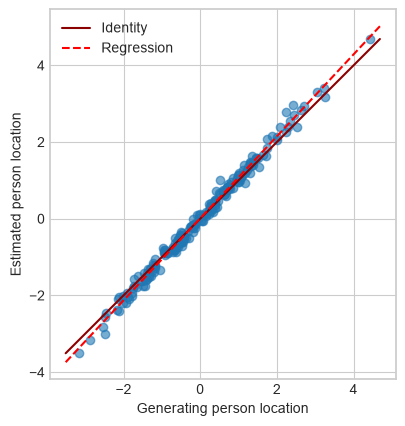

person location Pearson correlation:              0.996
person location SD ratio (estimated / generating): 1.074
person location regression coefficient:            1.069
person location RMSE:                              0.157


In [23]:
recovery_plot(mfrm.generating.persons, mfrm.persons_thresholds, 'person location', 'my_mfrm_thresholds_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [24]:
%%time
mfrm.test_stats_df_thresholds()
mfrm.test_stats_thresholds.to_csv('mfrm_thresholds_test_stats.csv')

CPU times: user 1.93 ms, sys: 603 μs, total: 2.54 ms
Wall time: 2.4 ms


Check the test statistics table

In [25]:
mfrm.test_stats_thresholds

,Items,Persons
Mean,-0.000,0.009
SD,0.736,1.420
Separation ratio,17.700,11.250
Strata,23.933,15.334
Reliability,0.997,0.992


Run an item residual correlation analysis (and check run time), and save relevant output to file

In [26]:
%%time
mfrm.item_res_corr_analysis_thresholds()
mfrm.item_residual_correlations_thresholds.to_csv('mfrm_thresholds_item_residual_correlations.csv')
mfrm.item_loadings_thresholds.to_csv('mfrm_thresholds_item_loadings.csv')

CPU times: user 6.12 ms, sys: 1.59 ms, total: 7.72 ms
Wall time: 8.84 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [27]:
round(mfrm.item_residual_correlations_thresholds, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Item_1,1.000,0.000,-0.007,0.005,0.011,0.021,-0.010,-0.037,0.007,-0.012,-0.006,-0.046
Item_2,0.000,1.000,-0.031,0.015,-0.017,-0.026,0.011,-0.032,0.007,-0.005,-0.024,-0.025
Item_3,-0.007,-0.031,1.000,-0.012,0.006,0.034,-0.037,-0.022,-0.019,-0.040,0.012,-0.033
Item_4,0.005,0.015,-0.012,1.000,-0.023,-0.051,0.036,-0.001,-0.024,0.015,-0.026,-0.009
Item_5,0.011,-0.017,0.006,-0.023,1.000,-0.019,0.018,-0.030,0.025,0.016,0.015,-0.020
Item_6,0.021,-0.026,0.034,-0.051,-0.019,1.000,-0.059,0.008,0.010,0.032,-0.013,-0.034
Item_7,-0.010,0.011,-0.037,0.036,0.018,-0.059,1.000,-0.009,0.009,0.019,-0.028,0.014
Item_8,-0.037,-0.032,-0.022,-0.001,-0.030,0.008,-0.009,1.000,0.006,-0.027,-0.031,-0.001
Item_9,0.007,0.007,-0.019,-0.024,0.025,0.010,0.009,0.006,1.000,-0.025,-0.003,0.031
Item_10,-0.012,-0.005,-0.040,0.015,0.016,0.032,0.019,-0.027,-0.025,1.000,-0.011,-0.022


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [28]:
round(mfrm.item_loadings_thresholds['PC 1'], 3)

Item_1     0.059
Item_2    -0.080
Item_3     0.146
Item_4    -0.127
Item_5     0.019
Item_6     0.177
Item_7    -0.166
Item_8    -0.008
Item_9    -0.003
Item_10   -0.022
Item_11    0.075
Item_12   -0.083
Name: PC 1, dtype: float64

Run a rater residual correlation analysis (and check run time), and save relevant output to file

In [29]:
%%time
mfrm.rater_res_corr_analysis_thresholds()
mfrm.rater_residual_correlations_thresholds.to_csv('mfrm_thresholds_rater_residual_correlations.csv')
mfrm.rater_loadings_thresholds.to_csv('mfrm_thresholds_rater_loadings.csv')

CPU times: user 8.18 ms, sys: 543 μs, total: 8.72 ms
Wall time: 8.67 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [30]:
round(mfrm.rater_residual_correlations_thresholds, 3)

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000,-0.009,-0.018,0.001,-0.026,0.025,0.013,-0.014
Rater_2,-0.009,1.000,0.029,-0.043,-0.017,-0.019,-0.010,0.005
Rater_3,-0.018,0.029,1.000,-0.056,-0.029,0.009,-0.015,-0.026
Rater_4,0.001,-0.043,-0.056,1.000,-0.023,-0.009,0.006,0.002
Rater_5,-0.026,-0.017,-0.029,-0.023,1.000,-0.035,0.026,-0.012
Rater_6,0.025,-0.019,0.009,-0.009,-0.035,1.000,-0.025,-0.033
Rater_7,0.013,-0.010,-0.015,0.006,0.026,-0.025,1.000,-0.023
Rater_8,-0.014,0.005,-0.026,0.002,-0.012,-0.033,-0.023,1.000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [31]:
round(mfrm.rater_loadings_thresholds['PC 1'], 3)

Rater_1   -0.054
Rater_2    0.143
Rater_3    0.261
Rater_4   -0.238
Rater_5   -0.075
Rater_6    0.086
Rater_7   -0.072
Rater_8   -0.052
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

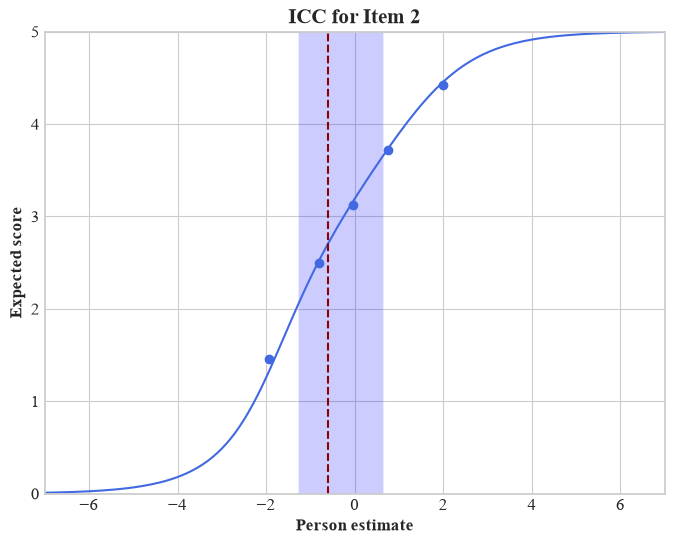

In [32]:
mfrm.icc_thresholds('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_thresholds_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

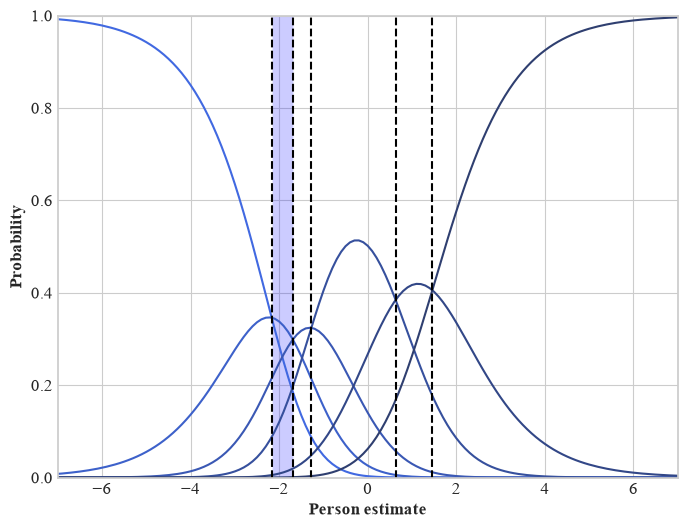

In [33]:
mfrm.crcs_thresholds('Item_2', thresh_lines=True, cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_thresholds_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

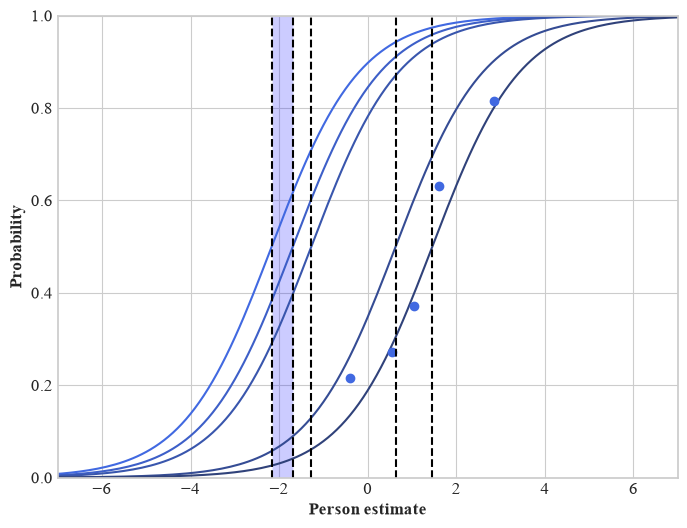

In [34]:
mfrm.threshold_ccs_thresholds('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_thresholds_threshold_ccs')

Produce an item information function curve for Item 2

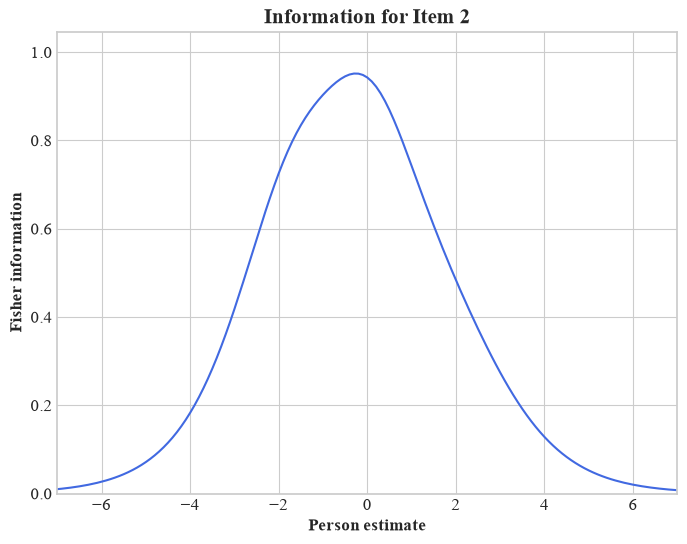

In [35]:
mfrm.iic_thresholds('Item_2', title='Information for Item 2', xmin=-7, xmax=7, filename='my_mfrm_thresholds_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 150 and 250 (aggregated across all raters) plotted.

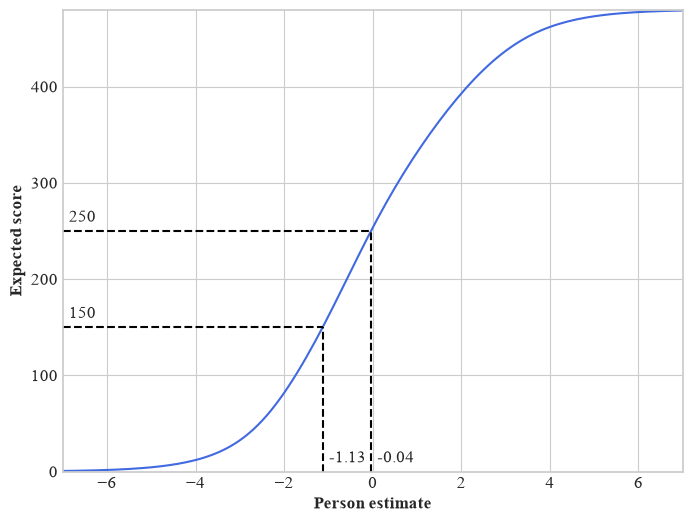

In [36]:
mfrm.tcc_thresholds(score_lines=[150, 250], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_thresholds_tcc')

Produce a test information curve

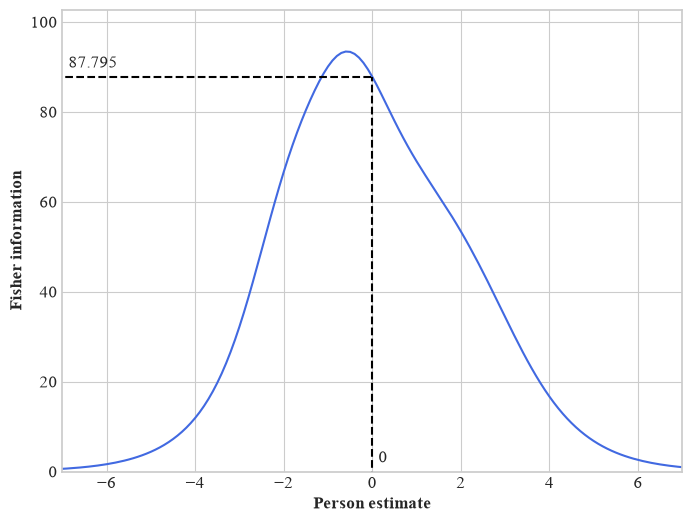

In [37]:
mfrm.test_info_thresholds(point_info_lines=[0], point_info_labels=True, xmin=-7, xmax=7, filename='my_mfrm_thresholds_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

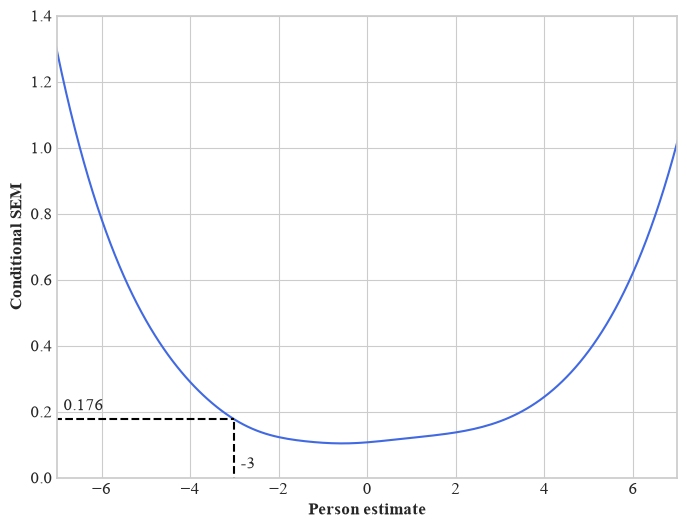

In [38]:
mfrm.test_csem_thresholds(point_csem_lines=[-3], point_csem_labels=True, ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_thresholds_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

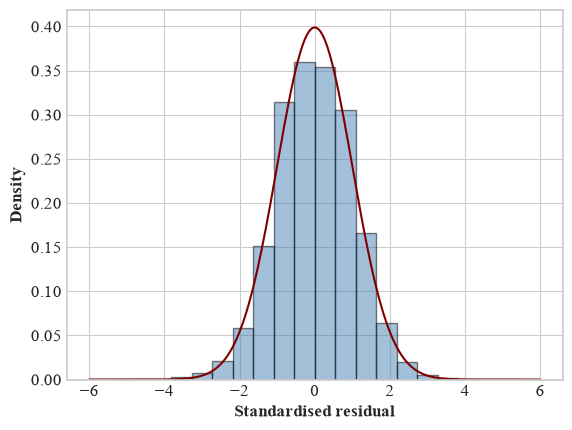

In [39]:
mfrm.std_residuals_plot_thresholds(bin_width=0.6, normal=True, filename='my_mfrm_thresholds_std_residuals_plot')

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [40]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_thresholds_anchor(anchors)

CPU times: user 1 ms, sys: 203 μs, total: 1.21 ms
Wall time: 1.14 ms


Check the anchored thresholds against the unanchored thresholds

In [41]:
threshold_check = pd.DataFrame({'Unanchored': mfrm.thresholds,
                           'Anchored': mfrm.anchor_thresholds_thresholds})
round(threshold_check, 3)

,Unanchored,Anchored
1,-1.560,-1.967
2,-1.082,-0.754
3,-0.665,-0.502
4,1.239,1.109
5,2.068,2.114


Check the anchored rater x threshold severities against the unanchored ones (two separate dataframes).

In [42]:
round(mfrm.raters_thresholds, 3)

,1,2,3,4,5
Rater_1,-0.224,0.220,1.081,-0.152,0.659
Rater_2,-1.005,-0.130,0.343,-0.776,-0.816
Rater_3,-0.095,0.862,0.109,1.062,0.057
Rater_4,-0.187,0.479,-0.765,-0.538,0.404
Rater_5,0.325,-0.622,0.161,0.341,0.412
Rater_6,0.074,-0.184,0.029,-0.004,-0.048
Rater_7,0.633,0.057,-0.259,-0.350,0.200
Rater_8,0.477,-0.682,-0.698,0.417,-0.869


In [43]:
round(mfrm.anchor_raters_thresholds, 3)

,1,2,3,4,5
Rater_1,0.154,-0.138,0.889,-0.051,0.583
Rater_2,-0.627,-0.488,0.151,-0.675,-0.893
Rater_3,0.283,0.504,-0.083,1.163,-0.019
Rater_4,0.191,0.121,-0.957,-0.437,0.328
Rater_5,0.703,-0.979,-0.031,0.442,0.336
Rater_6,0.452,-0.542,-0.163,0.096,-0.124
Rater_7,1.011,-0.300,-0.451,-0.249,0.124
Rater_8,0.855,-1.040,-0.890,0.518,-0.945
